In [100]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt

In [101]:
data = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [102]:
data.head() #this just gives a preview of the data we're working with!

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [103]:
data = np.array(data) #we're doing this because we dont want to use a pandas array. using a np array would allow us to manipulate it
m, n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train = data[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]

X_train = X_train.astype(np.float32) / 255. #normalizing it for the pixels
X_dev = X_dev.astype(np.float32) / 255.

Y_train = Y_train.astype(int)
Y_dev = Y_dev.astype(int)

In [104]:
# def init_params():
#     W1 = np.random.randn(10, 784) * 0.01
#     b1 = np.zeros((10, 1))
#     W2 = np.random.randn(10, 10) * 0.01
#     b2 = np.zeros((10, 1))
#     return W1, b1, W2, b2

def init_params():
    W1 = np.random.randn(10, 784) * 0.01
    b1 = np.zeros((10, 1))
    W2 = np.random.randn(10, 10) * 0.01
    b2 = np.zeros((10, 1))
    return W1, b1, W2, b2

def ReLU(Z):
    return np.maximum(0,Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)
    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X) +b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1) + b2
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def deriv_ReLU(Z):
    return Z > 0
    
def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y = one_hot(Y)
    dZ2 = A2 - one_hot_Y
    dW2 = 1 / m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)
    dZ1 = W2.T.dot(dZ2) * deriv_ReLU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [105]:
def get_predictions(A2):
    return np.argmax(A2, 0)
    
def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size
    
def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range(iterations):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i % 50 == 0:
            print("Iteration: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2

In [106]:
print(Y_train[:10])
print(Y_train.dtype)

[7 2 5 5 7 9 8 9 4 1]
int64


In [107]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 1000, 0.1)

Iteration:  0
[7 7 2 ... 7 2 7] [7 2 5 ... 0 1 3]
Accuracy:  0.09646341463414634
Iteration:  50
[7 7 1 ... 7 2 7] [7 2 5 ... 0 1 3]
Accuracy:  0.30365853658536585
Iteration:  100
[7 4 3 ... 0 3 2] [7 2 5 ... 0 1 3]
Accuracy:  0.5477073170731708
Iteration:  150
[7 4 3 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.7427560975609756
Iteration:  200
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.8128048780487804
Iteration:  250
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.8438292682926829
Iteration:  300
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.8627560975609756
Iteration:  350
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.8745365853658537
Iteration:  400
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.8830731707317073
Iteration:  450
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.887390243902439
Iteration:  500
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.8917804878048781
Iteration:  550
[7 2 5 ... 0 8 6] [7 2 5 ... 0 1 3]
Accuracy:  0.8951219512195122
Iteration:  600
[7

Prediction:  [4]
Label:  4


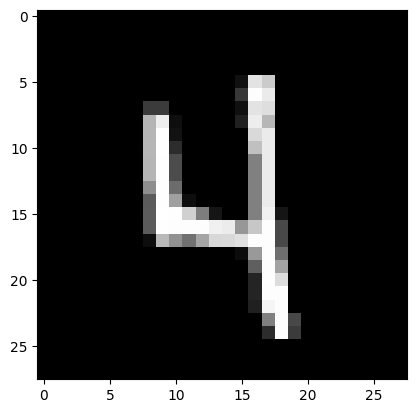

In [108]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

test_prediction(10, W1, b1, W2, b2)